In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo Excel en una variable llamada 'df' (Dataframe/Tabla)
df = pd.read_excel('Diagnostics.xlsx')

# Mostrar las primeras 5 filas para verificar que leyó bien el archivo
df.head()

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354


In [3]:
# Contar el número total de filas (registros)
total_registros = len(df)

# Suponiendo que cada archivo es un sujeto único
total_sujetos = df['FileName'].nunique()

print(f"Número total de registros: {total_registros}")
print(f"Número total de sujetos únicos: {total_sujetos}")

Número total de registros: 10646
Número total de sujetos únicos: 10646


In [4]:
# Obtener los valores únicos de la columna 'Rhythm'
tipos_arritmias = df['Rhythm'].unique()
print(f"Tipos de arritmias disponibles:\n {tipos_arritmias}")

Tipos de arritmias disponibles:
 ['AFIB' 'SB' 'SA' 'AF' 'SR' 'ST' 'SVT' 'AT' 'AVNRT' 'SAAWR' 'AVRT']


--- Tabla de Distribución ---


,Tipo de Arritmia,Número de Registros
0,SB,3889
1,SR,1826
2,AFIB,1780
3,ST,1568
4,SVT,587
5,AF,445
6,SA,399
7,AT,121
8,AVNRT,16
9,AVRT,8


/tmp/ipykernel_2399/1346408743.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_arritmias, x='Tipo de Arritmia', y='Número de Registros', palette='viridis')


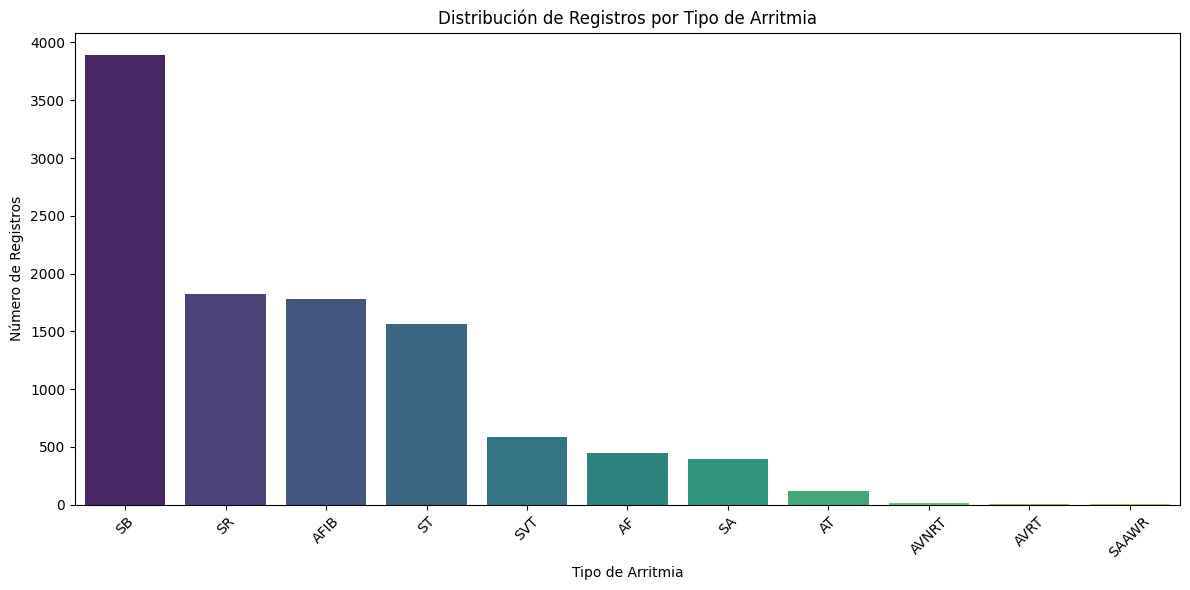

In [5]:
# Contar cuántos registros hay por cada tipo de arritmia
conteo_arritmias = df['Rhythm'].value_counts().reset_index()
conteo_arritmias.columns = ['Tipo de Arritmia', 'Número de Registros']

# Mostrar la tabla
print("--- Tabla de Distribución ---")
display(conteo_arritmias)

# Crear el gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=conteo_arritmias, x='Tipo de Arritmia', y='Número de Registros', palette='viridis')
plt.title('Distribución de Registros por Tipo de Arritmia')
plt.xlabel('Tipo de Arritmia')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
MUSE_20181222_204310_31000

In [6]:
import pandas as pd

# 1. Leer el archivo de la señal que acabas de subir
# (Si subiste uno con otro nombre, cámbialo aquí adentro de las comillas)
nombre_archivo = 'MUSE_20181222_204310_31000.csv'
senal_ejemplo = pd.read_csv(nombre_archivo)

# --- PASO 4: Canales y Derivaciones ---
# La forma (shape) de la tabla nos dice cuántas columnas (canales) tiene
num_canales = senal_ejemplo.shape[1]
nombres_canales = senal_ejemplo.columns.tolist()

print(f"--- PASO 4 ---")
print(f"Número de canales disponibles: {num_canales}")
print(f"Derivaciones: {nombres_canales}\n")

# --- PASO 5: Frecuencia y Duración ---
# La frecuencia de muestreo (Fs) es un dato técnico de la máquina que grabó esto (500 Hz según el fabricante)
fs = 500

# Contamos cuántas filas (muestras) tiene el archivo hacia abajo
num_muestras = len(senal_ejemplo)

# Calculamos el tiempo total dividiendo las muestras entre la frecuencia
duracion_segundos = num_muestras / fs

print(f"--- PASO 5 ---")
print(f"Frecuencia de muestreo (Fs): {fs} Hz")
print(f"Total de muestras registradas en el archivo: {num_muestras}")
print(f"Duración total del registro: {duracion_segundos} segundos")

--- PASO 4 ---
Número de canales disponibles: 12
Derivaciones: ['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.10', '0.11']

--- PASO 5 ---
Frecuencia de muestreo (Fs): 500 Hz
Total de muestras registradas en el archivo: 4999
Duración total del registro: 9.998 segundos


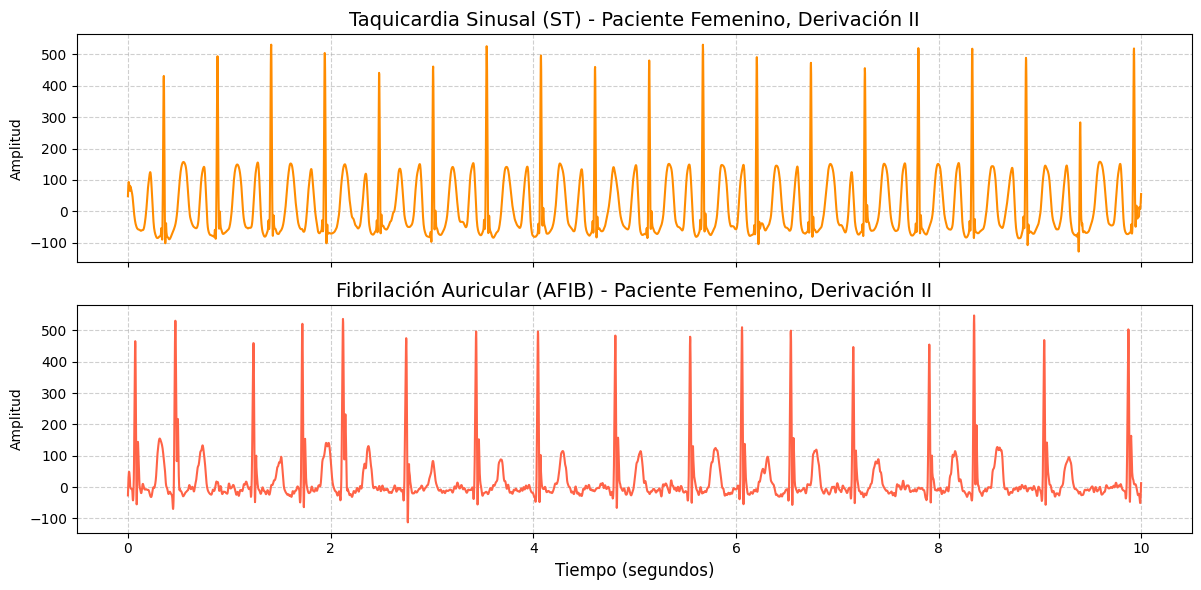

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Nombres exactos de los archivos que subiste
file_afib = 'MUSE_20180114_075026_69000.csv'
file_st = 'MUSE_20180113_131104_16000.csv'

# Nombres de las derivaciones
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# Leer los archivos
df_afib = pd.read_csv(file_afib, header=None, names=LEADS)
df_st = pd.read_csv(file_st, header=None, names=LEADS)

# Crear el vector de tiempo (10 segundos a 500 Hz)
fs = 500
tiempo = np.arange(len(df_afib)) / fs

# Crear la figura para comparar visualmente
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Graficar Taquicardia Sinusal (ST) arriba
ax1.plot(tiempo, df_st['II'], color='darkorange')
ax1.set_title('Taquicardia Sinusal (ST) - Paciente Femenino, Derivación II', fontsize=14)
ax1.set_ylabel('Amplitud')
ax1.grid(True, linestyle='--', alpha=0.6)

# Graficar Fibrilación Auricular (AFIB) abajo
ax2.plot(tiempo, df_afib['II'], color='tomato')
ax2.set_title('Fibrilación Auricular (AFIB) - Paciente Femenino, Derivación II', fontsize=14)
ax2.set_xlabel('Tiempo (segundos)', fontsize=12)
ax2.set_ylabel('Amplitud')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Morfología: En la señal ST (arriba) se observa un ciclo cardíaco altamente repetitivo y predecible; a pesar de la ondulación marcada en la línea base, cada latido conserva exactamente la misma forma que el anterior. En contraste, la señal AFIB (abajo) carece de un patrón estable entre latidos, presentando una línea base con oscilaciones finas y caóticas (ondas fibrilatorias) que evidencian la ausencia de una onda P normal.

Amplitud: Ambas señales son comparables en energía. Los picos máximos (complejos QRS) en la paciente con ST alcanzan valores estables alrededor de los 500, al igual que los picos de la paciente con AFIB (entre 450 y 500). Esto demuestra que la fuerza eléctrica de la contracción ventricular es similar en ambas arritmias.

Frecuencia cardíaca: Al contabilizar los latidos en la ventana de 10 segundos, la señal ST presenta 19 complejos QRS, lo que se traduce en una frecuencia de 114 latidos por minuto (lpm), confirmando el cuadro de taquicardia (>100 lpm). Por su parte, la señal AFIB presenta 18 complejos, equivalentes a 108 lpm, indicando un ritmo que también es acelerado.

Regularidad: Esta es la diferencia diagnóstica y matemática más importante. En la ST, el intervalo de tiempo entre cada pico máximo es constante y exacto a lo largo de los 10 segundos, comportándose como un metrónomo. En la AFIB, la distancia horizontal entre los picos es totalmente errática; hay latidos muy agrupados y otros con pausas largas, lo cual es el sello característico de esta patología.

,Taquicardia Sinusal (ST),Fibrilación Auricular (AFIB)
Media,13.607421,21.241662
Desviación Estándar,99.681775,77.959456
Máximo,530.970000,547.990000
Mínimo,-128.310000,-112.970000
Frecuencia Cardíaca (lpm),114.000000,102.000000
RMS,100.606253,80.801516


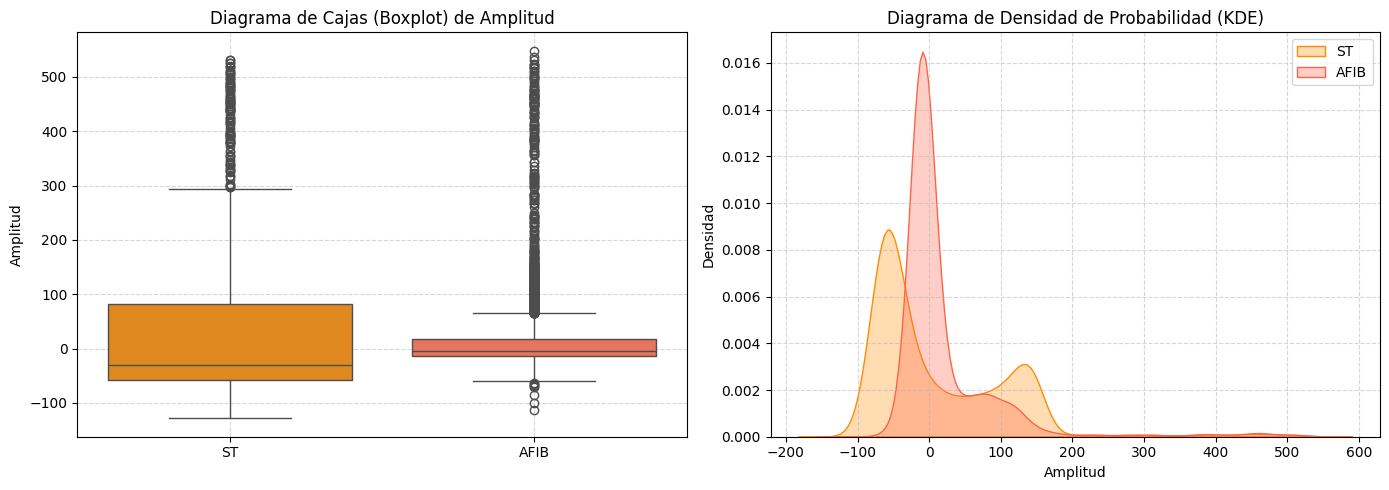

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

# Extraer los arreglos numéricos de la derivación II
sig_st = df_st['II'].values
sig_afib = df_afib['II'].values
fs = 500

# Detección automática de picos R para calcular la Frecuencia Cardíaca
peaks_st, _ = find_peaks(sig_st, height=200, distance=int(fs * 0.3))
peaks_afib, _ = find_peaks(sig_afib, height=200, distance=int(fs * 0.3))

fc_st = len(peaks_st) * 6
fc_afib = len(peaks_afib) * 6

# Función para calcular los parámetros descriptivos
def obtener_estadisticas(senal, fc):
    return {
        'Media': np.mean(senal),
        'Desviación Estándar': np.std(senal),
        'Máximo': np.max(senal),
        'Mínimo': np.min(senal),
        'Frecuencia Cardíaca (lpm)': fc,
        'RMS': np.sqrt(np.mean(senal**2))
    }

# Crear DataFrame comparativo
res_st = obtener_estadisticas(sig_st, fc_st)
res_afib = obtener_estadisticas(sig_afib, fc_afib)

tabla_comparativa = pd.DataFrame([res_st, res_afib], index=['Taquicardia Sinusal (ST)', 'Fibrilación Auricular (AFIB)']).T
display(tabla_comparativa)

# --- GRÁFICOS DESCRIPTIVOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot (Diagrama de cajas)
df_box = pd.DataFrame({'ST': sig_st, 'AFIB': sig_afib})
sns.boxplot(data=df_box, ax=axes[0], palette=['darkorange', 'tomato'])
axes[0].set_title('Diagrama de Cajas (Boxplot) de Amplitud')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Diagrama de Densidad (KDE)
sns.kdeplot(sig_st, ax=axes[1], color='darkorange', label='ST', fill=True, alpha=0.3)
sns.kdeplot(sig_afib, ax=axes[1], color='tomato', label='AFIB', fill=True, alpha=0.3)
axes[1].set_title('Diagrama de Densidad de Probabilidad (KDE)')
axes[1].set_xlabel('Amplitud')
axes[1].set_ylabel('Densidad')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Fibrilación Auricular (AFIB): El caos de bajo voltaje
El letargo eléctrico (KDE y Boxplot): En un ritmo normal, las aurículas (cámaras superiores) se contraen simultáneamente enviando un pulso fuerte que dibuja la onda P. En la AFIB, la fisiología falla: las aurículas no se contraen, sino que tiemblan de forma caótica debido a múltiples "chisporroteos" eléctricos simultáneos. Al no haber una contracción sincronizada, el electrocardiógrafo registra casi todo el tiempo un voltaje muy bajo o nulo. Esto explica por qué en tu diagrama de densidad (KDE) la AFIB tiene un pico rojo, alto y agudo, exactamente en el cero. La caja estrecha del boxplot confirma que la señal pasa la inmensa mayoría de los 10 segundos inactiva en la línea isoelectrica, registrando solo "ruido" auricular.

La respuesta ventricular (Valores atípicos): Para proteger al corazón de ese caos auricular, el nodo auriculoventricular actúa como un peaje y solo deja pasar unos pocos de esos impulsos hacia abajo. Cuando el impulso logra pasar, los ventrículos se contraen fuertemente. Esos latidos aislados son los puntos negros (outliers) que ves por encima de la caja roja en el boxplot. Rompen el silencio eléctrico de forma súbita, pero sin un patrón de tiempo regular.

Taquicardia Sinusal (ST): El ciclo estructurado y veloz
Actividad eléctrica constante (KDE bimodal): Fisiológicamente, la Taquicardia Sinusal conserva toda la ruta eléctrica intacta. El marcapasos natural (nodo sinusal) simplemente está disparando más rápido debido a estrés, ejercicio o fiebre. Como la ruta está sana, se forman ondas P completas, complejos QRS estructurados y ondas T de repolarización muy marcadas. El corazón nunca se queda en silencio. Por eso la curva naranja del KDE forma dos montañas; la señal está oscilando constantemente entre cargas positivas y negativas sin quedarse estancada en el cero.

Mayor energía global (RMS y Varianza): Al conservar un ciclo de contracción y relajación fuerte y organizado, el corazón en ST moviliza una masa eléctrica mucho mayor por segundo. Esto explica matemáticamente por qué el valor RMS (la energía eficaz, con 100.6) y la desviación estándar (99.6) son notablemente superiores a los de la AFIB. El boxplot ancho demuestra que los voltajes de esta paciente abarcan un rango dinámico mucho mayor a causa de ondas estructuradas constantes.

La coincidencia en los ventrículos (Amplitud Máxima)
A pesar de ser patologías tan distintas, los valores máximos de amplitud (ST: 530.9, AFIB: 547.9) son estadísticamente idénticos. Fisiológicamente, esto es totalmente congruente. La Fibrilación Auricular es una enfermedad de las aurículas. Una vez que el impulso eléctrico logra bajar, el miocardio de los ventrículos (que genera el pico máximo R) se contrae con la misma masa muscular, fuerza y voltaje que lo haría un ventrículo sano en una Taquicardia Sinusal.

Las métricas que calculaste son la prueba matemática de que, mientras la Taquicardia Sinusal es un corazón trabajando rápido pero ordenado, la Fibrilación Auricular es un corazón con aurículas eléctricamente estancadas que dependen de latidos ventriculares irregulares para sobrevivir.